# AquaSentinel — 03. Evaluation and explainability

This is the risk-aware core of the project. We:

1. Choose a decision threshold **on purpose**, using cross-validated predictions on the
   training set, targeting high recall on the UNSAFE class
2. Quantify what that choice costs in extra lab tests
3. Spend the test set **once** and report bootstrap confidence intervals
4. Look at ROC/PR curves, the confusion matrix and calibration
5. Explain the model with permutation importance and SHAP, and compare what it learned
   against what the drinking-water guidelines say should matter
6. Analyse the errors and state the limitations honestly

All numbers are read back from `results/metrics/`, written by `scripts/run_all.py`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image

from aquasentinel import config, data, evaluate, explain, features, models

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
evaluate.apply_style()


def load_metric(stem):
    """Read a results file written by scripts/run_all.py."""
    path = config.METRICS_DIR / f"{stem}.json"
    if path.exists():
        return json.loads(path.read_text(encoding="utf-8"))
    return pd.read_csv(config.METRICS_DIR / f"{stem}.csv")


print("Random seed:", config.RANDOM_SEED)

Random seed: 42


In [2]:
final = load_metric("final_evaluation")
raw = data.load_raw()
split = data.make_split(raw)

print("Best model:", final["best_model"])
print("Positive class:", final["label_mapping"]["positive_class"],
      "-", final["label_mapping"]["definition"])
print(f"Train rows: {final['n_train']:,}   Test rows: {final['n_test']:,}")
print(f"Unsafe prevalence in the test set: {final['test_unsafe_prevalence']:.1%}")

Best model: Random Forest
Positive class: UNSAFE - unsafe = 1 = (Potability == 0)
Train rows: 2,620   Test rows: 656
Unsafe prevalence in the test set: 61.0%


## 1. Choosing the decision threshold

The default 0.5 cut-off encodes the assumption that a false positive and a false negative
cost the same. For water safety they do not: sending a safe sample to the lab wastes a
test, while missing an unsafe sample is the failure the whole exercise exists to prevent.

So we select the threshold explicitly: **among all thresholds that reach at least 90%
recall on the UNSAFE class, keep the one with the best precision.** The selection runs on
*cross-validated predictions over the training set* — the test set is still untouched at
this point.

In [3]:
choice = final["threshold_choice"]
for key, value in choice.items():
    print(f"  {key:22s} {value}")

  threshold              0.43840211490565023
  target_recall          0.9
  achieved_recall        0.9005006257822278
  achieved_precision     0.675269826372595
  flag_rate              0.8133587786259542
  target_met             True


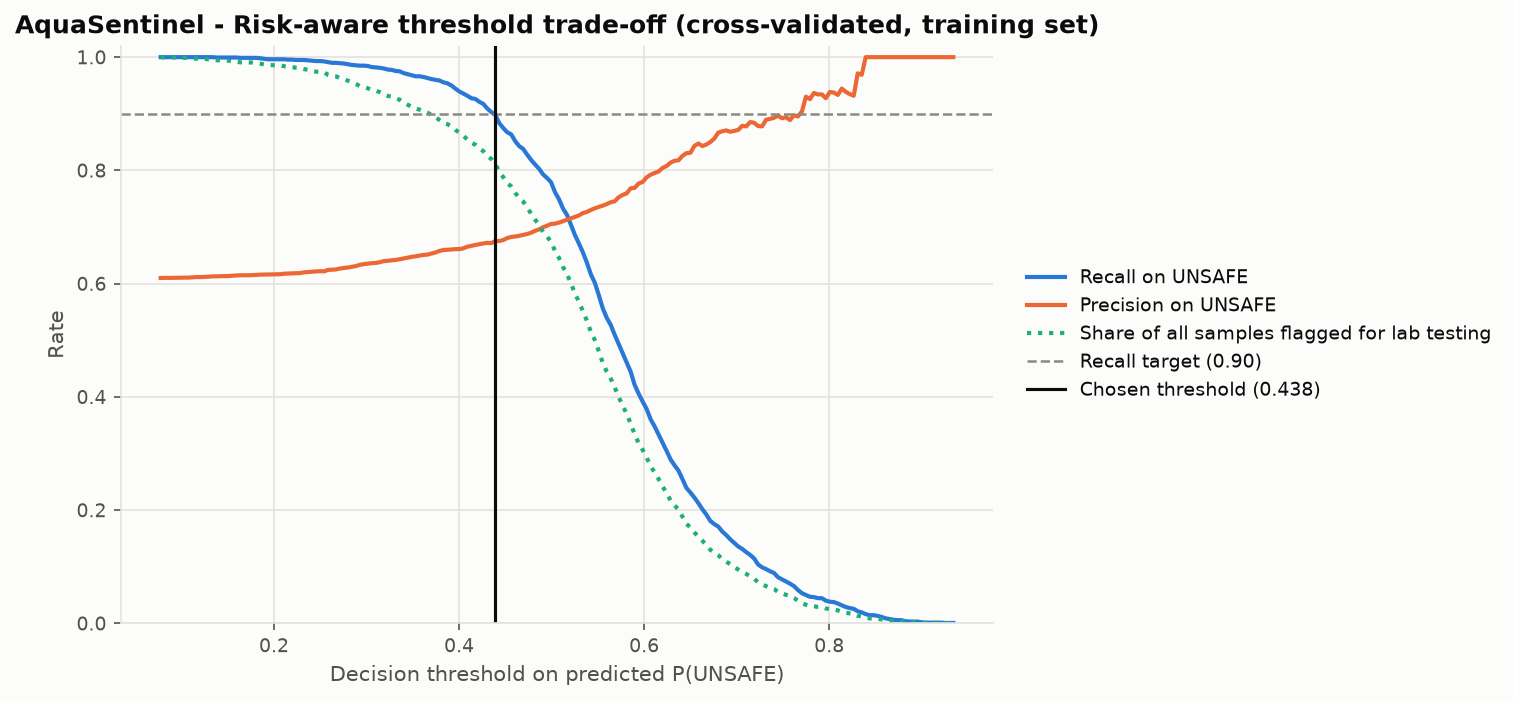

In [4]:
Image(str(config.FIGURES_DIR / "06_threshold_tradeoff.png"))

Reading the curve: as the threshold falls, recall (blue) rises toward 1.0 and precision
(orange) falls toward the base rate. The dotted green line is the share of all samples
that would be sent for lab testing. The vertical rule marks the chosen operating point —
where recall first reaches the 90% target.

In [5]:
sweep = pd.read_csv(config.METRICS_DIR / "threshold_sweep.csv")
near = sweep.iloc[(sweep["threshold"] - choice["threshold"]).abs().argsort()[:1]]
print("Cross-validated behaviour at and around the chosen threshold:\n")
sweep[(sweep["recall_unsafe"] >= 0.80) & (sweep["recall_unsafe"] <= 0.98)].iloc[::4].round(3)

Cross-validated behaviour at and around the chosen threshold:



,threshold,recall_unsafe,precision_unsafe,f1_unsafe,flag_rate
56,0.319,0.980,0.640,0.774,0.934
60,0.336,0.975,0.643,0.775,0.925
64,0.353,0.966,0.648,0.776,0.909
68,0.370,0.961,0.653,0.778,0.898
72,0.387,0.954,0.660,0.780,0.882
76,0.405,0.936,0.662,0.776,0.861
80,0.422,0.921,0.670,0.776,0.839
84,0.439,0.898,0.675,0.771,0.811
88,0.456,0.864,0.682,0.762,0.772
92,0.474,0.828,0.688,0.751,0.734


## 2. What the trade-off costs

The same model, the same test set, two different cut-offs.

In [6]:
at_chosen = final["final_model_test_at_chosen_threshold"]
at_default = final["final_model_test_at_default_threshold"]

comparison = pd.DataFrame({
    "default_0.5": at_default,
    f"chosen_{choice['threshold']:.3f}": at_chosen,
}).loc[[
    "recall_unsafe", "precision_unsafe", "f1_unsafe", "balanced_accuracy",
    "flag_rate", "true_positives", "false_negatives", "false_positives", "true_negatives",
]]
comparison["change"] = comparison.iloc[:, 1] - comparison.iloc[:, 0]
comparison.round(3)

,default_0.5,chosen_0.438,change
recall_unsafe,0.742,0.888,0.145
precision_unsafe,0.699,0.674,-0.025
f1_unsafe,0.720,0.766,0.046
balanced_accuracy,0.621,0.608,-0.013
flag_rate,0.648,0.803,0.155
true_positives,297.000,355.000,58.000
false_negatives,103.000,45.000,-58.000
false_positives,128.000,172.000,44.000
true_negatives,128.000,84.000,-44.000


In [7]:
extra_caught = at_chosen["true_positives"] - at_default["true_positives"]
extra_tests = at_chosen["false_positives"] - at_default["false_positives"]
total_unsafe = at_chosen["true_positives"] + at_chosen["false_negatives"]

print(f"Moving from the 0.5 cut-off to {choice['threshold']:.3f}:")
print(f"  catches {extra_caught} more unsafe samples (of {total_unsafe} unsafe in the test set)")
print(f"  at the cost of {extra_tests} more safe samples sent for lab testing")
if extra_caught:
    print(f"  = {extra_tests / extra_caught:.1f} extra lab tests per additional unsafe sample caught")

Moving from the 0.5 cut-off to 0.438:
  catches 58 more unsafe samples (of 400 unsafe in the test set)
  at the cost of 44 more safe samples sent for lab testing
  = 0.8 extra lab tests per additional unsafe sample caught


## 3. The test set, spent once

Final model vs. both baselines, with 2,000-resample bootstrap percentile intervals.

In [8]:
cis = final["final_model_test_bootstrap_ci_95"]
rule = final["rule_baseline_test"]
dummy = final["dummy_baseline_test"]

rows = []
for metric in ("roc_auc", "pr_auc", "recall_unsafe", "precision_unsafe",
               "f1_unsafe", "balanced_accuracy", "flag_rate"):
    interval = cis.get(metric)
    rows.append({
        "metric": metric,
        final["best_model"]: round(at_chosen[metric], 3),
        "95% CI": f"[{interval['lower']:.3f}, {interval['upper']:.3f}]" if interval else "-",
        "rule baseline": round(rule[metric], 3),
        "dummy baseline": round(dummy[metric], 3),
    })
pd.DataFrame(rows).set_index("metric")

,Random Forest,95% CI,rule baseline,dummy baseline
metric,,,,
roc_auc,0.693,"[0.651, 0.733]",0.484,0.500
pr_auc,0.752,"[0.705, 0.800]",0.608,0.610
recall_unsafe,0.887,"[0.854, 0.918]",1.000,1.000
precision_unsafe,0.674,"[0.634, 0.712]",0.610,0.610
f1_unsafe,0.766,"[0.735, 0.794]",0.758,0.758
balanced_accuracy,0.608,"[0.574, 0.641]",0.500,0.500
flag_rate,0.803,-,1.000,1.000


In [9]:
print("Unsafe samples MISSED (false negatives) on the test set:")
print(f"  {final['best_model']:28s} {at_chosen['false_negatives']}")
print(f"  {'Guideline rule baseline':28s} {rule['false_negatives']}")
print(f"  {'Dummy (majority class)':28s} {dummy['false_negatives']}")
print("\nShare of all samples sent for lab testing:")
print(f"  {final['best_model']:28s} {at_chosen['flag_rate']:.1%}")
print(f"  {'Guideline rule baseline':28s} {rule['flag_rate']:.1%}")
print(f"  {'Dummy (majority class)':28s} {dummy['flag_rate']:.1%}")

Unsafe samples MISSED (false negatives) on the test set:
  Random Forest                45
  Guideline rule baseline      0
  Dummy (majority class)       0

Share of all samples sent for lab testing:
  Random Forest                80.3%
  Guideline rule baseline      100.0%
  Dummy (majority class)       100.0%


## 4. Curves, confusion matrix and calibration

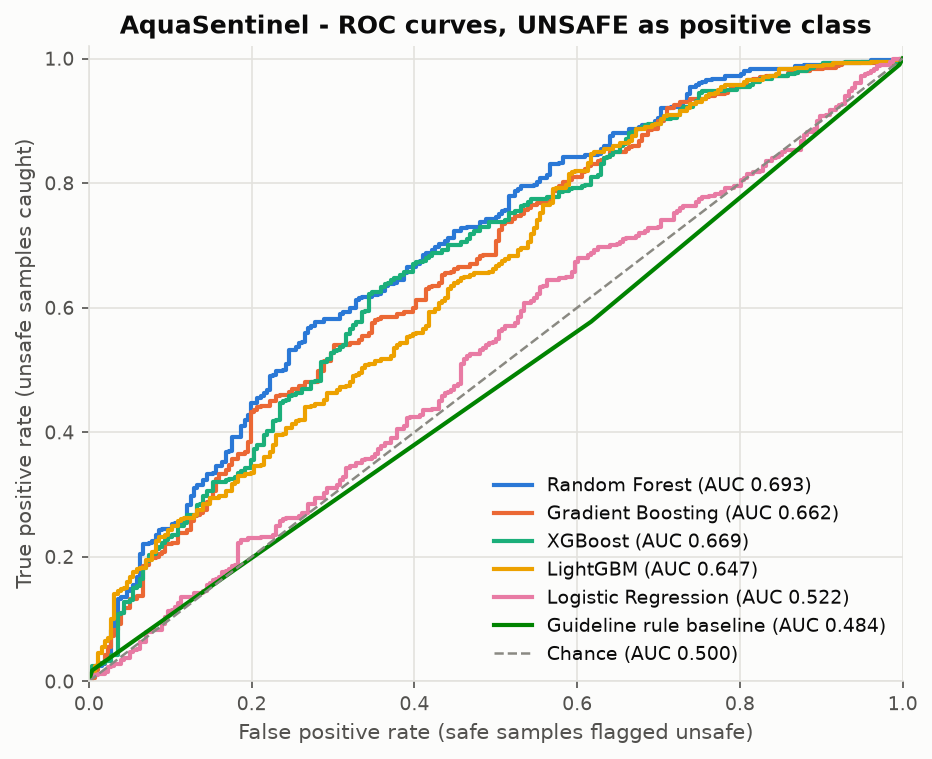

In [10]:
Image(str(config.FIGURES_DIR / "07_roc_curves.png"))

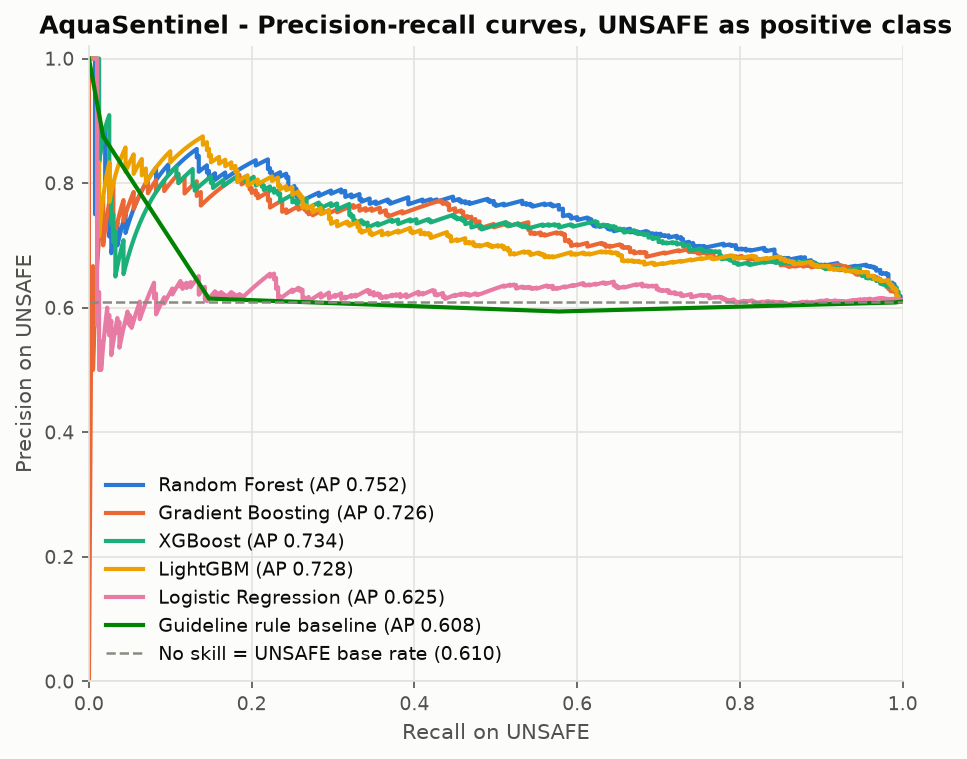

In [11]:
Image(str(config.FIGURES_DIR / "08_pr_curves.png"))

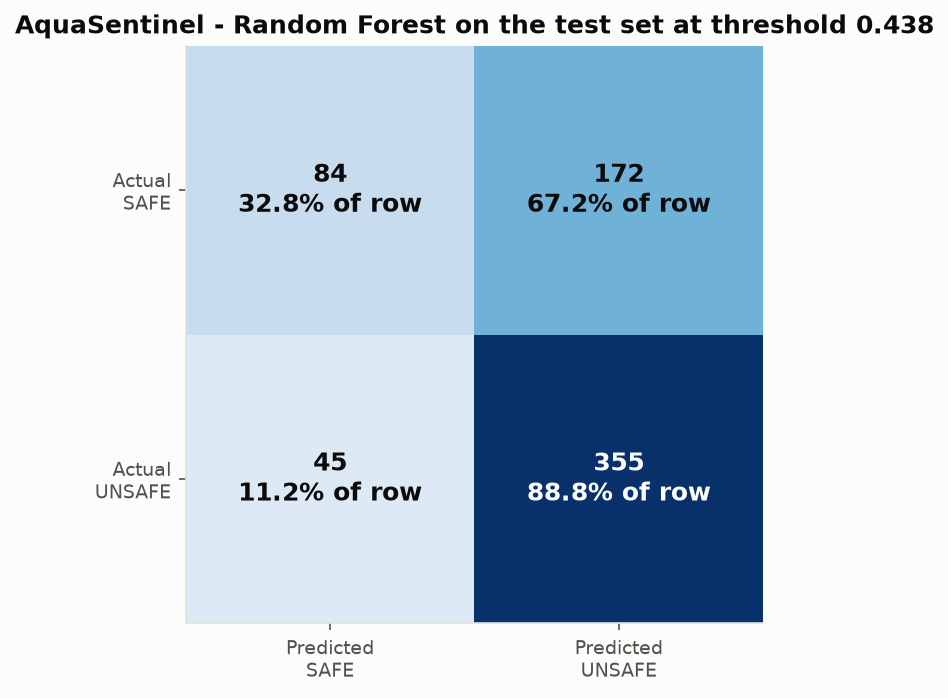

In [12]:
Image(str(config.FIGURES_DIR / "09_confusion_matrix.png"))

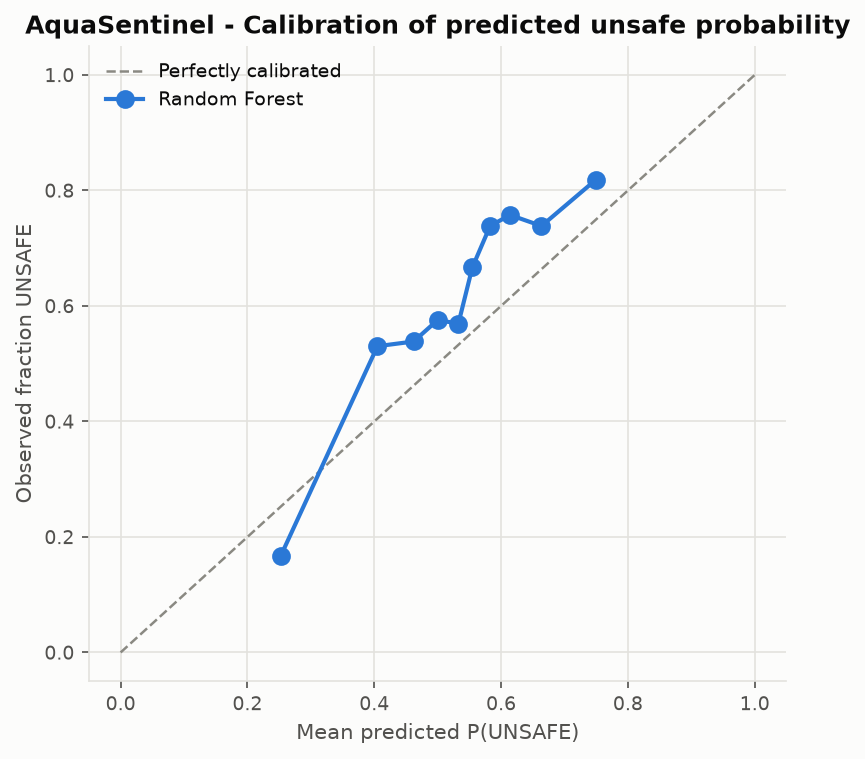

In [13]:
Image(str(config.FIGURES_DIR / "10_calibration.png"))

In [14]:
print(f"Brier score (lower is better): {at_chosen['brier']:.4f}")
print(f"Brier score of always predicting the base rate: "
      f"{final['test_unsafe_prevalence'] * (1 - final['test_unsafe_prevalence']):.4f}")

Brier score (lower is better): 0.2168
Brier score of always predicting the base rate: 0.2380


## 5. Explainability

### Permutation importance on held-out data

Features are shuffled in their raw form, before preprocessing, so each number is attributable to the named physicochemical parameter.

In [15]:
importance = pd.read_csv(config.METRICS_DIR / "permutation_importance.csv")
importance["in_guideline_rule"] = importance["feature"].isin(config.PARAMETER_LIMITS)
importance.round(4)

,feature,importance_mean,importance_std,in_guideline_rule
0,ph,0.1139,0.0145,True
1,Sulfate,0.1019,0.0182,True
2,Hardness,0.0633,0.0067,True
3,Solids,0.0404,0.0098,True
4,Chloramines,0.0382,0.0100,True
5,Trihalomethanes,0.0044,0.0040,True
6,Turbidity,0.0026,0.0036,True
7,Organic_carbon,0.0023,0.0040,False
8,Conductivity,-0.0016,0.0058,False


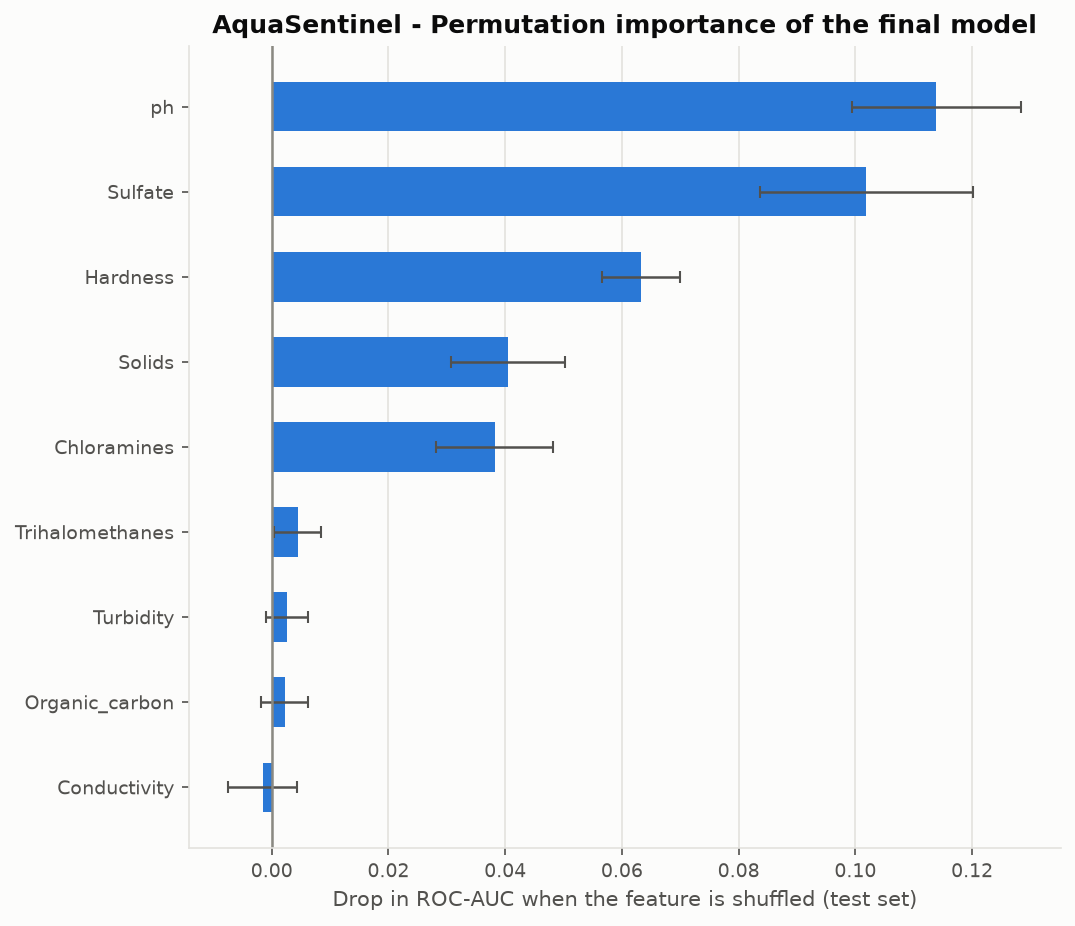

In [16]:
Image(str(config.FIGURES_DIR / "11_permutation_importance.png"))

### SHAP

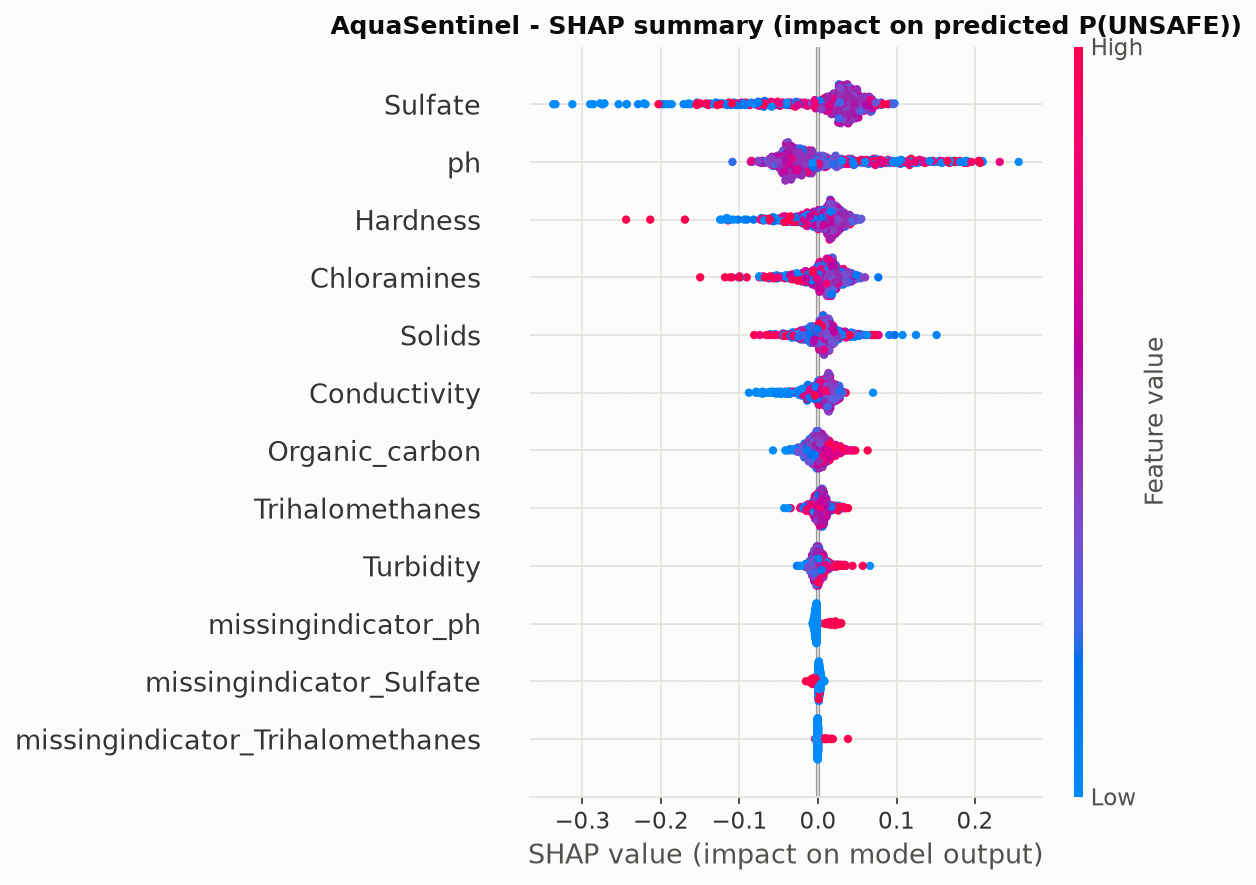

In [17]:
Image(str(config.FIGURES_DIR / "12_shap_summary.png"))

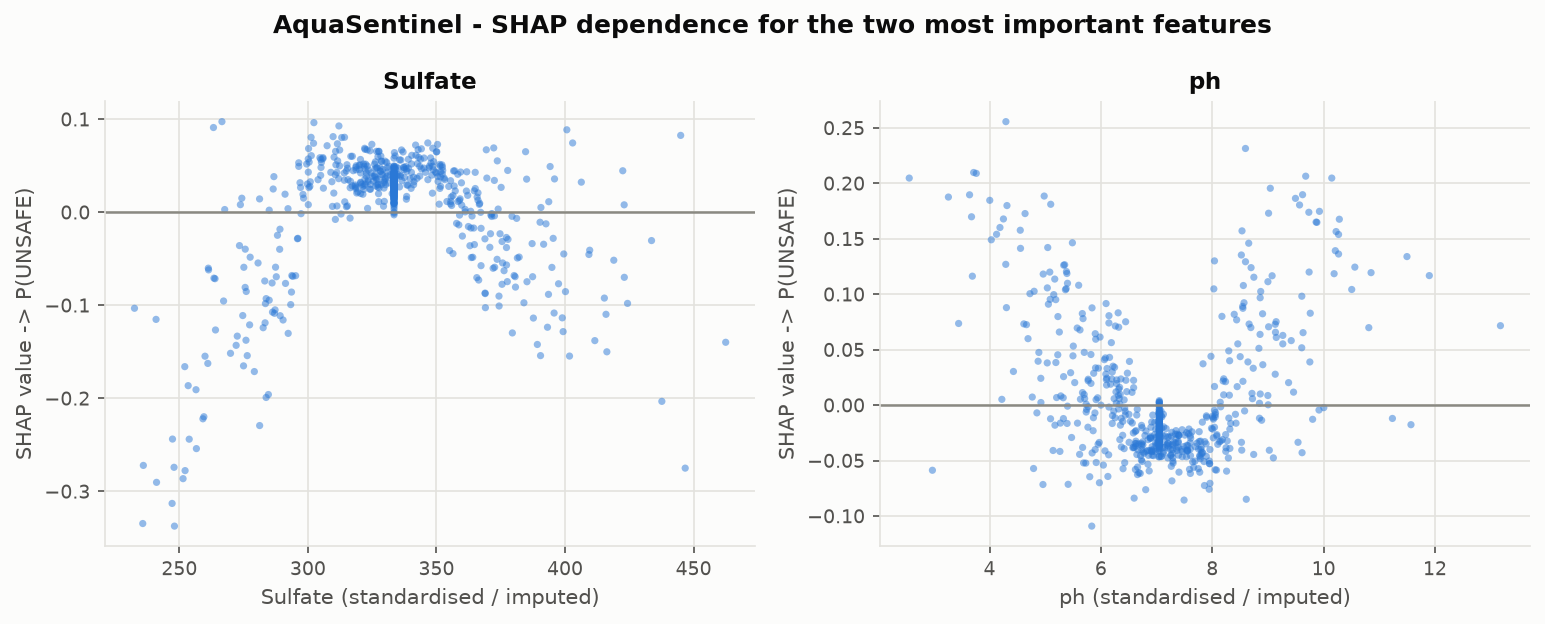

In [18]:
Image(str(config.FIGURES_DIR / "13_shap_dependence.png"))

### Data-driven importance vs. domain expectation

The guidelines say the parameters that determine whether water is safe to drink are pH,
hardness, TDS, chloramines, sulfate, trihalomethanes and turbidity — these are the seven
for which we could verify a numeric limit. Conductivity and organic carbon have no
verifiable drinking-water threshold.

If the dataset's labels were generated by anything resembling real drinking-water
standards, the model's importance ranking should concentrate on the regulated parameters
with limits that actually bite.

In [19]:
ranked = importance.sort_values("importance_mean", ascending=False).reset_index(drop=True)
ranked["rank"] = ranked.index + 1
in_rule = ranked[ranked["in_guideline_rule"]]
not_in_rule = ranked[~ranked["in_guideline_rule"]]

print("Mean importance of parameters WITH a verified guideline limit: "
      f"{in_rule['importance_mean'].mean():.4f}")
print("Mean importance of parameters WITHOUT one:                     "
      f"{not_in_rule['importance_mean'].mean():.4f}")
print(f"\nTop 3 by the model: {list(ranked.head(3)['feature'])}")
print(f"Of those, in the guideline rule: {list(ranked.head(3).loc[ranked.head(3)['in_guideline_rule'], 'feature'])}")
print(f"\nLargest single importance: {ranked['importance_mean'].max():.4f} ROC-AUC")
print("For context, the model's total margin over chance is "
      f"{at_chosen['roc_auc'] - 0.5:.4f} ROC-AUC.")

Mean importance of parameters WITH a verified guideline limit: 0.0521
Mean importance of parameters WITHOUT one:                     0.0003

Top 3 by the model: ['ph', 'Sulfate', 'Hardness']
Of those, in the guideline rule: ['ph', 'Sulfate', 'Hardness']

Largest single importance: 0.1139 ROC-AUC
For context, the model's total margin over chance is 0.1933 ROC-AUC.


**Where they agree and where they diverge — and it is not where you would expect.**

The agreement is actually *strong*, and in the model's favour: the three parameters the
model leans on hardest (`ph`, `Sulfate`, `Hardness`) are all regulated parameters with
verified limits, and the two parameters we had to exclude from the rule for lack of a
verifiable limit (`Organic_carbon`, `Conductivity`) are also the two the model finds
almost **useless** — mean permutation importance 0.0003 against 0.0521 for the regulated
set, with `Conductivity` scoring slightly negative, i.e. pure noise.

So the data and the domain agree on **which parameters carry information**.

They diverge on **where the dividing lines sit**. The guideline rule, built from those
same parameters, still performs no better than chance, and no single feature is worth
much ROC-AUC on its own. The model is not finding "pH is out of the 6.5–8.5 band";
it is finding weak multivariate structure whose decision boundaries have no relationship
to any published limit. That is a coherent picture: the right *variables*, the wrong
*thresholds* — consistent with labels that were not generated from drinking-water
standards.


## 6. Error analysis

Which samples does the model get wrong, and is there a pattern we could fix?

In [20]:
errors = load_metric("error_analysis")
pd.Series(errors["outcome_counts"], name="count").to_frame()

,count
true_positive,355
false_positive,172
true_negative,84
false_negative (MISSED UNSAFE),45


In [21]:
print(f"Median predicted P(UNSAFE) for unsafe samples CAUGHT:  {errors['caught_unsafe_score_median']:.3f}")
print(f"Median predicted P(UNSAFE) for unsafe samples MISSED:  {errors['missed_unsafe_score_median']:.3f}")
print(f"Chosen threshold:                                      {choice['threshold']:.3f}")

Median predicted P(UNSAFE) for unsafe samples CAUGHT:  0.582
Median predicted P(UNSAFE) for unsafe samples MISSED:  0.395
Chosen threshold:                                      0.438


In [22]:
medians = pd.read_csv(config.METRICS_DIR / "error_analysis_group_medians.csv", index_col=0)
medians

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
outcome,,,,,,,,,
false_negative (MISSED UNSAFE),6.989,197.374,21318.962,7.881,329.404,389.638,13.425,68.976,3.853
false_positive,6.810,190.423,20432.842,7.240,333.062,416.342,13.994,67.009,3.939
true_negative,7.276,195.540,21728.534,7.256,312.091,425.223,14.160,67.329,4.114
true_positive,7.024,196.035,19909.542,7.016,331.215,427.545,14.034,67.106,3.993


In [23]:
missed_vs_caught = pd.read_csv(config.METRICS_DIR / "error_analysis_missed_vs_caught.csv")
missed_vs_caught = missed_vs_caught.assign(
    relative_gap=lambda d: (d["median_gap"] / d["median_caught_unsafe"]).abs()
).sort_values("relative_gap", ascending=False)
missed_vs_caught.round(3)

,feature,median_missed_unsafe,median_caught_unsafe,median_gap,relative_gap
3,Chloramines,7.881,7.016,0.865,0.123
5,Conductivity,389.638,427.545,-37.907,0.089
2,Solids,21318.962,19909.542,1409.420,0.071
6,Organic_carbon,13.425,14.034,-0.608,0.043
8,Turbidity,3.853,3.993,-0.140,0.035
7,Trihalomethanes,68.976,67.106,1.870,0.028
1,Hardness,197.374,196.035,1.340,0.007
4,Sulfate,329.404,331.215,-1.810,0.005
0,ph,6.989,7.024,-0.035,0.005


### Reconstructing the misclassified samples directly

`scripts/run_all.py` writes the final model's exact test-set predictions to
`results/metrics/test_predictions.csv`. We load those rather than refitting the model
here: refitting inside a notebook kernel is not guaranteed to reproduce the script's fit
bit-for-bit (thread pools and library state differ), and a silently different model would
make this error analysis describe something other than the reported results.


In [24]:
predictions = pd.read_csv(config.METRICS_DIR / "test_predictions.csv")
scores = predictions["score_unsafe"].to_numpy()
y_true = predictions["y_true_unsafe"].to_numpy()

reproduced = evaluate.classification_metrics(y_true, scores, choice["threshold"])
for key in ("roc_auc", "pr_auc", "recall_unsafe", "precision_unsafe", "false_negatives"):
    match = np.isclose(reproduced[key], at_chosen[key])
    print(f"{key:20s} notebook={reproduced[key]:<10.4f} script={at_chosen[key]:<10.4f} match={match}")

roc_auc              notebook=0.6933     script=0.6933     match=True
pr_auc               notebook=0.7519     script=0.7519     match=True
recall_unsafe        notebook=0.8875     script=0.8875     match=True
precision_unsafe     notebook=0.6736     script=0.6736     match=True
false_negatives      notebook=45.0000    script=45.0000    match=True


In [25]:
frame = split.x_test.copy()
frame["y_true"] = y_true
frame["score"] = scores
frame["y_pred"] = (scores >= choice["threshold"]).astype(int)
missed = frame[(frame.y_true == 1) & (frame.y_pred == 0)]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.hist(frame.loc[frame.y_true == 0, "score"], bins=35, alpha=0.55,
        color=evaluate.SERIES_COLORS[0], label="Actually SAFE")
ax.hist(frame.loc[frame.y_true == 1, "score"], bins=35, alpha=0.55,
        color=evaluate.SERIES_COLORS[1], label="Actually UNSAFE")
ax.axvline(choice["threshold"], color=evaluate.INK_PRIMARY, linewidth=1.5,
           label=f"Threshold ({choice['threshold']:.3f})")
ax.set_xlabel("Predicted P(UNSAFE)")
ax.set_ylabel("Number of test samples")
ax.set_title("AquaSentinel - Predicted score distribution by true class")
ax.legend()
plt.tight_layout()
plt.show()

print(f"The two score distributions overlap almost entirely. {len(missed)} unsafe samples")
print("fall below the threshold, and they do not occupy a distinctive region of feature")
print("space - there is no sub-population the model could be repaired to catch.")

The two score distributions overlap almost entirely. 45 unsafe samples
fall below the threshold, and they do not occupy a distinctive region of feature
space - there is no sub-population the model could be repaired to catch.


C:\Users\mohan\AppData\Local\Temp\ipykernel_20336\4117480821.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 7. Limitations

- **Label quality is unknown and probably the binding constraint.** The Kaggle page does
  not say how `Potability` was determined. The data is widely believed to be synthetic or
  semi-synthetic. A ceiling around ROC-AUC 0.68 with nine informative-sounding chemical
  parameters is more consistent with weakly-related labels than with a hard problem.
- **The `Solids` column contradicts its documented units** (median ≈ 21,000 ppm against a
  2,000 mg/L permissible limit), which makes the guideline rule fire on nearly every row.
- **Substantial missingness** in `Sulfate` (23.8%), `ph` (15.0%) and `Trihalomethanes`
  (4.9%). It appears unrelated to the target, but it is imputed, not measured.
- **No time, location, source or treatment information.** Each row is an isolated snapshot,
  so nothing can be said about trends, seasonality or specific supplies.
- **3,276 rows is small** for learning subtle interactions among nine continuous features;
  the bootstrap intervals on the test metrics are correspondingly wide.
- **Two of nine parameters are missing from the rule baseline** because no numeric
  drinking-water limit could be verified for conductivity or total organic carbon.
- **This is an analysis of a public dataset, not a deployed monitoring system.** Nothing
  here should be used to decide that any real water is safe to drink.

## 8. Conclusions

1. **A model can hold ~90% recall on unsafe samples, but only by flagging most of the
   supply.** That is the honest headline, and it is the number a lab-prioritisation
   decision would actually turn on.
2. **The gain over "test everything" is small but real.** The final model beats the dummy
   on precision at matched recall; the question is whether the saved tests justify the
   missed samples.
3. **Published drinking-water standards do not explain these labels.** A rule built from
   verified WHO/BIS/EPA limits performs barely above chance.
4. **Only tree ensembles find any signal at all** — logistic regression sits at chance, so
   whatever structure exists is non-linear and interaction-driven.
5. **The errors are not fixable by tuning.** Missed and caught unsafe samples have almost
   identical score distributions and feature profiles.

See the top-level `README.md` for the full results tables, which are generated
automatically from these same results files.